In [1]:
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.preprocessing import normalize, StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
df = pd.read_csv('dataset.csv')

**EDA**

In [3]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

artists       1
album_name    1
track_name    1
dtype: int64


In [4]:
print(df.dtypes)

Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object


In [5]:
genre_counts = df["track_genre"].value_counts()
print(f"Num of unique genres: {len(genre_counts)}")
print(f"Min samples per genre: {genre_counts.min()}")
print(f"Max samples per genre: {genre_counts.max()}")
print(genre_counts.head(5))

Num of unique genres: 114
Min samples per genre: 1000
Max samples per genre: 1000
track_genre
acoustic       1000
afrobeat       1000
alt-rock       1000
alternative    1000
ambient        1000
Name: count, dtype: int64


In [6]:
print(f"Rows where tempo == 0: {(df['tempo'] == 0).sum()}")

Rows where tempo == 0: 157


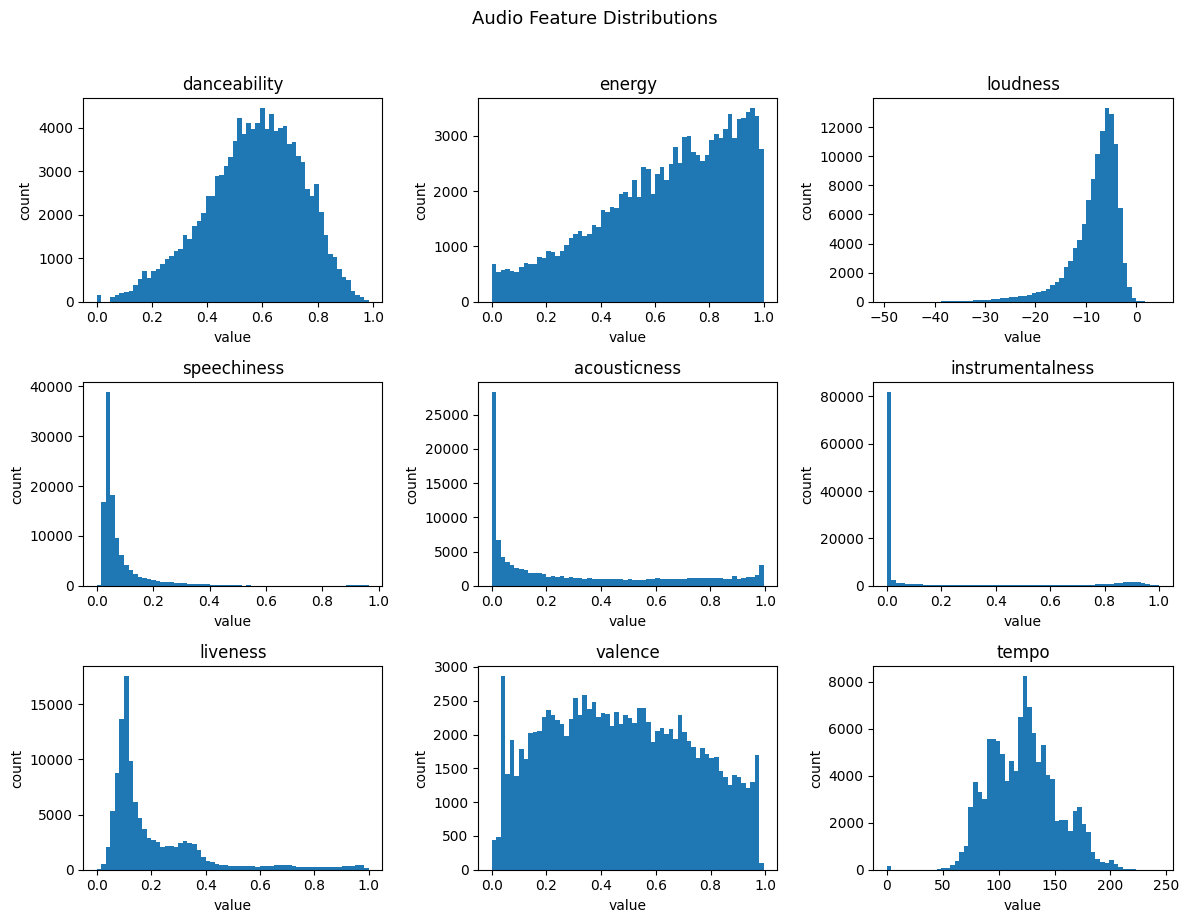

In [7]:
audio_features = [
    "danceability", "energy", "loudness", "speechiness",
    "acousticness", "instrumentalness", "liveness", "valence", "tempo"
]

fig, axes = plt.subplots(3, 3, figsize=(12, 9))
axes = axes.flatten()

for i, feature in enumerate(audio_features):
    axes[i].hist(df[feature], bins=60, edgecolor="none")
    axes[i].set_title(feature)
    axes[i].set_xlabel("value")
    axes[i].set_ylabel("count")

plt.suptitle("Audio Feature Distributions", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

**Correlation Analysis**

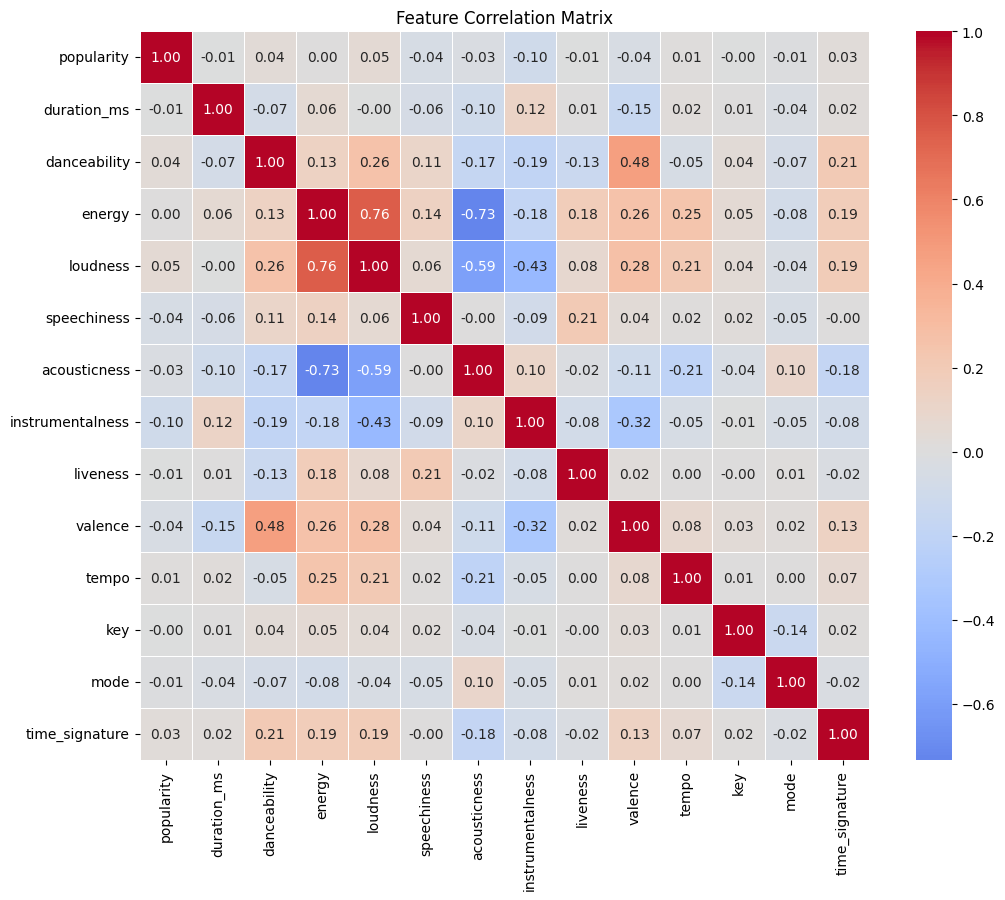

In [8]:
numeric_features = [
    "popularity", "duration_ms", "danceability", "energy", "loudness",
    "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "key", "mode", "time_signature"
]

corr_matrix = df[numeric_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.4,
    ax=ax
)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [9]:
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            print(f"{corr_matrix.columns[i]:20s} vs {corr_matrix.columns[j]:20s}  r = {r:.3f}")

energy               vs loudness              r = 0.762
energy               vs acousticness          r = -0.734
loudness             vs acousticness          r = -0.590


In [10]:
scale_summary = df[numeric_features].agg(["min", "max", "mean", "std"]).T
scale_summary.columns = ["min", "max", "mean", "std"]
print(scale_summary.round(3).to_string())

                     min          max        mean         std
popularity         0.000      100.000      33.239      22.305
duration_ms        0.000  5237295.000  228029.153  107297.713
danceability       0.000        0.985       0.567       0.174
energy             0.000        1.000       0.641       0.252
loudness         -49.531        4.532      -8.259       5.029
speechiness        0.000        0.965       0.085       0.106
acousticness       0.000        0.996       0.315       0.333
instrumentalness   0.000        1.000       0.156       0.310
liveness           0.000        1.000       0.214       0.190
valence            0.000        0.995       0.474       0.259
tempo              0.000      243.372     122.148      29.978
key                0.000       11.000       5.309       3.560
mode               0.000        1.000       0.638       0.481
time_signature     0.000        5.000       3.904       0.433


**Cleaning**

In [11]:
df_clean = df.drop_duplicates(subset="track_id", keep="first").copy()
print(f"After dedup by track_id: {df_clean.shape}")

After dedup by track_id: (89741, 21)


In [12]:
metadata_cols = ["Unnamed: 0", "track_id", "artists", "album_name", "track_name"]

metadata = df_clean[["track_name", "artists", "track_genre"]].copy()
df_clean = df_clean.drop(columns=metadata_cols)
print(f"After dropping metadata cols: {df_clean.shape}")

After dropping metadata cols: (89741, 16)


In [13]:
df_clean = df_clean.dropna()
metadata = metadata.loc[df_clean.index]
print(f"After dropping null rows: {df_clean.shape}")

After dropping null rows: (89741, 16)


In [14]:
#remove tempo since there can be no songs with 0 tempo
#this means if it is 0, it is invalid data
tempo_mask = df_clean["tempo"] != 0

df_clean = df_clean[tempo_mask].reset_index(drop=True)
metadata = metadata[tempo_mask.values].reset_index(drop=True)
print(f"After filtering tempo = 0: {df_clean.shape}")

After filtering tempo = 0: (89584, 16)


In [15]:
df_clean["explicit"] = df_clean["explicit"].astype(int)

In [16]:
print(f"\nFinal cleaned shape: {df_clean.shape}")
print(f"\nDtypes after encoding:")
print(df_clean.dtypes)
print(f"\nRemaining nulls: {df_clean.isnull().sum().sum()}")


Final cleaned shape: (89584, 16)

Dtypes after encoding:
popularity            int64
duration_ms           int64
explicit              int64
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

Remaining nulls: 0


In [17]:
feature_cols = ["popularity", "duration_ms", "danceability", "energy", "loudness",
    "speechiness", "acousticness", "instrumentalness", "liveness",
    "valence", "tempo", "key", "mode", "time_signature"
]

In [18]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_genre_ohe = ohe.fit_transform(metadata[["track_genre"]])

print(f"One-hot genre shape: {X_genre_ohe.shape}")
print(f"Sample categories: {ohe.categories_[0][:5]}")

One-hot genre shape: (89584, 113)
Sample categories: ['acoustic' 'afrobeat' 'alt-rock' 'alternative' 'ambient']


In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean[feature_cols])

print(f"X_scaled shape: {X_scaled.shape}")

X_scaled shape: (89584, 14)


In [20]:
genre_scaler = StandardScaler()
X_genre_scaled = genre_scaler.fit_transform(X_genre_ohe)

print(f"X_genre_scaled shape: {X_scaled.shape}")

X_genre_scaled shape: (89584, 14)


In [21]:
feature_weights = {
    "popularity": 1.0,
    "duration_ms": 1.0,
    "danceability": 1.0,
    "energy": 1.0,
    "loudness": 1.0,
    "speechiness": 1.0,
    "acousticness": 1.0,
    "instrumentalness": 1.0,
    "liveness": 1.0,
    "valence": 1.0,
    "tempo": 1,
    "key": 1.0,
    "mode": 1.0,
    "time_signature": 1.0,
}
#feature weight
weight_vector = np.array([feature_weights[col] for col in feature_cols])
X_weighted = X_scaled * weight_vector

n_genre_cols = X_genre_ohe.shape[1]
genre_weight = 1.25 / np.sqrt(n_genre_cols)
X_genre_weighted = X_genre_scaled * genre_weight

print(f"Weight vector: {weight_vector}")
print(f"X_weighted shape: {X_weighted.shape}")

Weight vector: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
X_weighted shape: (89584, 14)


In [22]:
scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

verification = scaled_df.agg(["mean", "std"]).T
verification.columns = ["mean", "std"]
print(verification.round(4).to_string())

                  mean  std
popularity        -0.0  1.0
duration_ms       -0.0  1.0
danceability      -0.0  1.0
energy            -0.0  1.0
loudness          -0.0  1.0
speechiness        0.0  1.0
acousticness      -0.0  1.0
instrumentalness   0.0  1.0
liveness          -0.0  1.0
valence            0.0  1.0
tempo             -0.0  1.0
key               -0.0  1.0
mode              -0.0  1.0
time_signature     0.0  1.0


**Parameter Tuning**

In [23]:
P_AUDIO_ONLY = 0.1712

def composite_score(precisions, diversities, alpha=0.5,
                    diversity_floor=0.10, p_audio_only=P_AUDIO_ONLY):

    mean_precision = np.mean(precisions)
    mean_diversity = np.mean(diversities)

    # Hard floor — disqualify configs with insufficient diversity
    # Prevents search from converging on genre-filter solutions
    if mean_diversity < diversity_floor:
        return -1.0, mean_precision, mean_diversity

    # Circularity penalty — discount configs where genre does most of the work
    # A fully audio-driven model has circularity=0; fully genre-driven has circularity=1
    if mean_precision > 0:
        circularity = (mean_precision - p_audio_only) / mean_precision
        circularity_discount = 1.0 - (0.3 * circularity)
    else:
        circularity_discount = 1.0

    score = (alpha * mean_precision + (1 - alpha) * mean_diversity) \
            * circularity_discount

    return score, mean_precision, mean_diversity

In [24]:
from itertools import product
import time

def evaluate_config(genre_wt, mode_wt, energy_wt, pca_var):
    trial_weights = {col: 1.0 for col in feature_cols}
    trial_weights["mode"]   = mode_wt
    trial_weights["energy"] = energy_wt

    w_vec = np.array([trial_weights[col] for col in feature_cols])
    X_audio_trial = X_scaled * w_vec

    # PCA on audio only — genre is concatenated after, not compressed with audio
    pca_trial = PCA(n_components=pca_var, svd_solver="full")
    X_pca_trial = pca_trial.fit_transform(X_audio_trial)

    g_weight = genre_wt / np.sqrt(n_genre_cols)
    X_combined_trial = np.hstack([X_pca_trial, X_genre_scaled * g_weight])
    X_norm_trial = normalize(X_combined_trial, norm="l2")

    knn_trial = NearestNeighbors(metric="cosine", algorithm="brute")
    knn_trial.fit(X_norm_trial)

    precisions = []
    diversities = []

    for idx in eval_indices:
        qv = X_norm_trial[idx].reshape(1, -1)
        _, idxs = knn_trial.kneighbors(qv, n_neighbors=11)
        neighbors = [i for i in idxs[0] if i != idx][:10]

        # Precision — genre coherence
        query_genre = metadata.loc[idx, "track_genre"]
        matches = sum(
            metadata.loc[i, "track_genre"] == query_genre for i in neighbors
        )
        precisions.append(matches / 10)

        # Diversity — average pairwise cosine distance among recommendations
        vecs = X_norm_trial[neighbors]
        pairwise = [
            1 - np.dot(vecs[i], vecs[j])
            for i in range(len(vecs))
            for j in range(i + 1, len(vecs))
        ]
        diversities.append(np.mean(pairwise) if pairwise else 0)

    return composite_score(precisions, diversities)


# Parameter space — genre weight capped at 1.5 to stay below the cliff
param_grid = {
    "genre_weight_multiplier": [0.5, 0.6, 0.75, 1.0, 1.1, 1.25, 1.5],
    "mode_weight":             [1.0, 1.5, 2.0],
    "energy_weight":           [1.0, 1.5, 2.0],
    "pca_variance":            [0.85, 0.90, 0.95]
}

np.random.seed(42)
eval_indices = np.random.choice(len(metadata), size=150, replace=False)

np.random.seed(99)
all_combos = list(product(
    param_grid["genre_weight_multiplier"],
    param_grid["mode_weight"],
    param_grid["energy_weight"],
    param_grid["pca_variance"]
))
sampled_combos = [
    all_combos[i] for i in
    np.random.choice(len(all_combos), size=25, replace=False)
]

results = []
for gw, mw, ew, pv in sampled_combos:
    start = time.time()
    score, prec, div = evaluate_config(gw, mw, ew, pv)
    elapsed = time.time() - start

    # Flag disqualified configs explicitly so you can see what failed
    status = "DISQUALIFIED (diversity too low)" if score < 0 else "OK"

    results.append({
        "genre_weight":  gw,
        "mode_weight":   mw,
        "energy_weight": ew,
        "pca_variance":  pv,
        "composite":     round(score, 4),
        "precision":     round(prec, 4),
        "diversity":     round(div, 4),
        "seconds":       round(elapsed, 1),
        "status":        status
    })

    print(f"gw={gw} mw={mw} ew={ew} pca={pv} → "
          f"composite={score:.4f} prec={prec:.4f} "
          f"div={div:.4f} [{status}]")

results_df = pd.DataFrame(results).sort_values("composite", ascending=False)

print("\n=== All configurations by composite score ===")
print(results_df.to_string(index=False))

# Filter to only qualified configs for top 5
qualified = results_df[results_df["status"] == "OK"]
print(f"\n=== Top 5 qualified configurations ===")
print(qualified.head(5)[
    ["genre_weight", "mode_weight", "energy_weight",
     "pca_variance", "composite", "precision", "diversity"]
].to_string(index=False))

# Apply safety checklist to the winner
if len(qualified) > 0:
    best = qualified.iloc[0]
    print(f"\n=== Safety checklist for best config ===")
    print(f"genre_weight={best['genre_weight']}  mode_weight={best['mode_weight']}  "
          f"energy_weight={best['energy_weight']}  pca_variance={best['pca_variance']}")

    checks = {
        "precision > 0.30 (not underfitting)":   best["precision"] > 0.30,
        "diversity >= 0.10 (not overfitting)":   best["diversity"] >= 0.10,
        "diversity <= 0.35 (not incoherent)":    best["diversity"] <= 0.35,
        "composite > 0 (passed diversity floor)": best["composite"] > 0,
    }

    all_passed = True
    for check, passed in checks.items():
        mark = "✓" if passed else "✗ FAIL"
        print(f"  [{mark}] {check}")
        if not passed:
            all_passed = False

    if all_passed:
        print("\n  Model is safe to use. Apply these parameters below.")
    else:
        print("\n  ⚠ Config failed safety checks. Expand search range and rerun.")
else:
    print("\n⚠ No qualified configurations found.")
    print("  All 25 trials had diversity below 0.10.")
    print("  Reduce genre_weight_multiplier range further (try max 1.0)")
    print("  or lower alpha in composite_score to penalize precision more.")

gw=0.6 mw=2.0 ew=1.5 pca=0.95 → composite=-1.0000 prec=0.3347 div=0.0900 [DISQUALIFIED (diversity too low)]
gw=0.6 mw=2.0 ew=2.0 pca=0.85 → composite=-1.0000 prec=0.3840 div=0.0641 [DISQUALIFIED (diversity too low)]
gw=1.1 mw=2.0 ew=2.0 pca=0.9 → composite=-1.0000 prec=0.7360 div=0.0970 [DISQUALIFIED (diversity too low)]
gw=0.75 mw=1.5 ew=1.5 pca=0.9 → composite=-1.0000 prec=0.4687 div=0.0996 [DISQUALIFIED (diversity too low)]
gw=1.5 mw=2.0 ew=1.5 pca=0.85 → composite=-1.0000 prec=0.9073 div=0.0949 [DISQUALIFIED (diversity too low)]
gw=0.75 mw=2.0 ew=1.5 pca=0.9 → composite=-1.0000 prec=0.5033 div=0.0835 [DISQUALIFIED (diversity too low)]
gw=0.5 mw=1.5 ew=1.0 pca=0.85 → composite=-1.0000 prec=0.3100 div=0.0800 [DISQUALIFIED (diversity too low)]
gw=0.75 mw=1.5 ew=2.0 pca=0.9 → composite=-1.0000 prec=0.4820 div=0.0880 [DISQUALIFIED (diversity too low)]
gw=0.6 mw=1.5 ew=1.0 pca=0.85 → composite=-1.0000 prec=0.3887 div=0.0875 [DISQUALIFIED (diversity too low)]
gw=1.0 mw=1.0 ew=1.0 pca=0.85

**Dimensionality Reduction**

In [25]:
pca = PCA()
pca.fit(X_weighted)


cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print("=== Explained variance by component ===")
for i, (individual, cumulative) in enumerate(
    zip(pca.explained_variance_ratio_, cumulative_variance), start=1
):
    print(f"PC{i:02d}:  {individual:.4f}  cumulative: {cumulative:.4f}")

=== Explained variance by component ===
PC01:  0.2108  cumulative: 0.2108
PC02:  0.1106  cumulative: 0.3214
PC03:  0.0928  cumulative: 0.4143
PC04:  0.0836  cumulative: 0.4978
PC05:  0.0742  cumulative: 0.5720
PC06:  0.0710  cumulative: 0.6430
PC07:  0.0631  cumulative: 0.7061
PC08:  0.0630  cumulative: 0.7691
PC09:  0.0597  cumulative: 0.8288
PC10:  0.0555  cumulative: 0.8844
PC11:  0.0511  cumulative: 0.9355
PC12:  0.0315  cumulative: 0.9670
PC13:  0.0232  cumulative: 0.9902
PC14:  0.0098  cumulative: 1.0000


In [26]:
pca = PCA(n_components=0.85, svd_solver="full")
X_pca = pca.fit_transform(X_weighted)

print(f"Components retained: {pca.n_components_}")
print(f"Explained variance captured: {pca.explained_variance_ratio_.sum():.4f}")
print(f"X_pca shape: {X_pca.shape}")

Components retained: 10
Explained variance captured: 0.8844
X_pca shape: (89584, 10)


In [27]:
X_combined = np.hstack([
    X_pca,
    X_genre_scaled * (genre_weight)
])

In [28]:
X_norm = normalize(X_combined, norm="l2")

print(f"X_norm shape: {X_norm.shape}")

X_norm shape: (89584, 123)


In [29]:
row_norms = np.linalg.norm(X_norm, axis=1)
print(f"Row norm min:  {row_norms.min():.6f}")
print(f"Row norm max:  {row_norms.max():.6f}")
print(f"Row norm mean: {row_norms.mean():.6f}")

Row norm min:  1.000000
Row norm max:  1.000000
Row norm mean: 1.000000


In [30]:
pre_norm_magnitudes = np.linalg.norm(X_pca, axis=1)
near_zero_threshold = 0.1
near_zero_count = (pre_norm_magnitudes < near_zero_threshold).sum()

print(f"Rows with pre-normalization magnitude < {near_zero_threshold}: {near_zero_count}")
print(f"As % of dataset: {near_zero_count / len(X_pca) * 100:.3f}%")

Rows with pre-normalization magnitude < 0.1: 0
As % of dataset: 0.000%


**KNN**

In [31]:
knn_index = NearestNeighbors(metric="cosine", algorithm="brute")
knn_index.fit(X_norm)

print(f"Index fitted on: {X_norm.shape[0]} tracks, {X_norm.shape[1]} dimensions")

Index fitted on: 89584 tracks, 123 dimensions


In [32]:
name_to_index = {
    f"{metadata.loc[idx, 'artists']} - {name}": idx
    for idx, name in enumerate(metadata["track_name"])
}

print(f"Tracks in lookup: {len(name_to_index)}")
print(f"Sample entries:")
for name in list(name_to_index.keys())[100:104]:
    print(f"  '{name}' → index {name_to_index[name]}")

Tracks in lookup: 81199
Sample entries:
  'Ben Rector - Love Like This' → index 127
  'Matt Nathanson - Come On Get Higher' → index 128
  'Rachael Yamagata - "Something In the Rain" (Something In the Rain, Pt. 1) [Music from the Original TV Series]' → index 129
  'Parachute - Kiss Me Slowly' → index 130


In [33]:
def find_keys(track_name):
    return [key for key in name_to_index if key.endswith(f"- {track_name}")]

In [34]:
def recommend_song(query_key, n_recommendations=10):
    if query_key not in name_to_index:
        raise ValueError(
            f"'{query_key}' not found. Use format: 'Artist — Track Name'"
        )

    query_idx = name_to_index[query_key]
    query_vector = X_norm[query_idx].reshape(1, -1)

    distances, indices = knn_index.kneighbors(
        query_vector, n_neighbors=n_recommendations + 1
    )

    similarities = 1 - distances[0]
    neighbor_indices = indices[0]

    results = []
    for sim, idx in zip(similarities, neighbor_indices):
        if idx == query_idx:
            continue
        results.append({
            "track_name": metadata.loc[idx, "track_name"],
            "artists":    metadata.loc[idx, "artists"],
            "genre":      metadata.loc[idx, "track_genre"],
            "similarity": round(sim, 4)
        })

    return pd.DataFrame(results).head(n_recommendations)

In [35]:
results = recommend_song("Nirvana - Rape Me", n_recommendations=10)
print(results.to_string(index=False))

                              track_name                artists  genre  similarity
I Hate Myself And Want To Die - 2013 Mix                Nirvana grunge      0.9479
                            Given to Fly              Pearl Jam grunge      0.9475
                 Rusty Cage - Remastered            Soundgarden grunge      0.9224
                       Doesn't Remind Me             Audioslave grunge      0.9193
                                Lifetime       Three Days Grace grunge      0.9155
                  Ana's Song (Open Fire)            Silverchair grunge      0.9106
                  Would? (2022 Remaster)        Alice In Chains grunge      0.9100
                   Today - 2011 Remaster  The Smashing Pumpkins grunge      0.8888
                       Selling The Drama                   Live grunge      0.8866
                          From Yesterday Thirty Seconds To Mars grunge      0.8856


Validation

In [36]:
def precision_at_k(query_key, k=10):
    query_genre = metadata.loc[
        name_to_index[query_key], "track_genre"
    ]
    recs = recommend_song(query_key, n_recommendations=k)
    matches = (recs["genre"] == query_genre).sum()
    return matches / k

In [37]:
np.random.seed(42)
sample_indices = np.random.choice(len(metadata), size=500, replace=False)
sample_tracks = [
    f"{metadata.loc[idx, 'artists']} - {metadata.loc[idx, 'track_name']}"
    for idx in sample_indices
]

precisions = []
for track in sample_tracks:
    try:
        p = precision_at_k(track, k=10)
        precisions.append(p)
    except ValueError:
        continue

mean_precision = np.mean(precisions)
median_precision = np.median(precisions)

print(f"Evaluated tracks:  {len(precisions)}")
print(f"Mean Precision@10: {mean_precision:.4f}")
print(f"Median Precision@10: {median_precision:.4f}")
print(f"Random baseline:   {1/114:.4f}")
print(f"Lift over random:  {mean_precision / (1/114):.1f}x")

print(f"Distribution:")
thresholds = [0.0, 0.1, 0.3, 0.5, 0.7, 1.0]
for lo, hi in zip(thresholds, thresholds[1:]):
    count = sum(lo <= p < hi for p in precisions)
    print(f"  [{lo:.1f}, {hi:.1f}): {count:4d} tracks  ({count/len(precisions)*100:.1f}%)")

Evaluated tracks:  500
Mean Precision@10: 0.8532
Median Precision@10: 1.0000
Random baseline:   0.0088
Lift over random:  97.3x
Distribution:
  [0.0, 0.1):   11 tracks  (2.2%)
  [0.1, 0.3):   15 tracks  (3.0%)
  [0.3, 0.5):   37 tracks  (7.4%)
  [0.5, 0.7):   33 tracks  (6.6%)
  [0.7, 1.0):   57 tracks  (11.4%)


In [38]:
def recommend_song_reranked(track_name, n_recommendations=10,
                             candidate_pool=50, artist_boost=0.05):
    if track_name not in name_to_index:
        raise ValueError(f"'{track_name}' not found in index.")

    query_idx = name_to_index[track_name]
    query_vector = X_norm[query_idx].reshape(1, -1)
    query_artist = metadata.loc[query_idx, "artists"]

    distances, indices = knn_index.kneighbors(
        query_vector, n_neighbors=candidate_pool + 1
    )
    similarities = 1 - distances[0]

    results = []
    for sim, idx in zip(similarities, indices[0]):
        if idx == query_idx:
            continue

        candidate_artist = metadata.loc[idx, "artists"]

        adjusted_sim = sim + artist_boost if candidate_artist == query_artist else sim

        results.append({
            "track_name":    metadata.loc[idx, "track_name"],
            "artists":       candidate_artist,
            "genre":         metadata.loc[idx, "track_genre"],
            "similarity":    round(sim, 4),
            "adjusted_sim":  round(adjusted_sim, 4)
        })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(
        "adjusted_sim", ascending=False
    ).head(n_recommendations)

    return results_df.reset_index(drop=True)

In [44]:
recommend_song_reranked("Aphex Twin - Xtal")

,track_name,artists,genre,similarity,adjusted_sim
0,Infinity (feat. Marie Angerer),Fejká;Marie Angerer,ambient,0.9821,0.9821
1,Haul - Radio Edit,Christian Löffler;Mohna,ambient,0.9671,0.9671
2,Beyond the Clouds,You'll Never Get to Heaven,ambient,0.9594,0.9594
3,Ken Tavr,Ishome,ambient,0.9515,0.9515
4,Choros - Remastered 2020,Ludovico Einaudi,ambient,0.9362,0.9362
5,Haul (feat. Mohna),Christian Löffler;Mohna,ambient,0.9280,0.9280
6,So Far,Ólafur Arnalds;Arnór Dan,ambient,0.8999,0.8999
7,New Fires,Christian Löffler;Henry Green,ambient,0.8981,0.8981
8,Dona Nobis Pacem 2,Max Richter;Mari Samuelsen;Konzerthausorcheste...,ambient,0.8887,0.8887
9,Lido,Bicep,ambient,0.8808,0.8808


In [46]:
import joblib
import os

In [47]:
os.makedirs("artifacts", exist_ok=True)

In [51]:
joblib.dump(scaler, "artifacts/scaler.pkl")
joblib.dump(pca, "artifacts/pca.pkl")
joblib.dump(ohe, "artifacts/onehot_encoder.pkl")
joblib.dump(knn_index, "artifacts/knn_index.pkl")
joblib.dump(X_norm, "artifacts/X_norm.pkl")
joblib.dump(name_to_index, "artifacts/name_to_index.pkl")
joblib.dump(metadata, "artifacts/metadata.pkl")
joblib.dump(feature_cols, "artifacts/feature_cols.pkl")
joblib.dump(feature_weights, "artifacts/feature_weights.pkl")

['artifacts/feature_weights.pkl']

In [52]:
print("Artifacts saved:")
for f in os.listdir("artifacts"):
    size_mb = os.path.getsize(f"artifacts/{f}") / 1e6
    print(f"  {f}: {size_mb:.1f} MB")

Artifacts saved:
  onehot_encoder.pkl: 0.0 MB
  X_norm.pkl: 88.2 MB
  feature_weights.pkl: 0.0 MB
  metadata.pkl: 3.3 MB
  scaler.pkl: 0.0 MB
  pca.pkl: 0.0 MB
  feature_cols.pkl: 0.0 MB
  name_to_index.pkl: 3.7 MB
  knn_index.pkl: 88.2 MB


In [53]:
def intra_list_diversity(query_key, k=10):
    recs = recommend_song(query_key, n_recommendations=k)
    rec_indices = [
        name_to_index.get(
            f"{recs.loc[i, 'artists']} - {recs.loc[i, 'track_name']}"
        )
        for i in range(len(recs))
    ]
    rec_indices = [i for i in rec_indices if i is not None]

    if len(rec_indices) < 2:
        return None

    pairwise_distances = []
    for i in range(len(rec_indices)):
        for j in range(i+1, len(rec_indices)):
            sim = np.dot(X_norm[rec_indices[i]], X_norm[rec_indices[j]])
            pairwise_distances.append(1 - sim)

    return np.mean(pairwise_distances)

np.random.seed(42)
diversity_scores = []
for key in sample_tracks[:200]:
    try:
        d = intra_list_diversity(key, k=10)
        if d is not None:
            diversity_scores.append(d)
    except:
        continue

print(f"Mean intra-list diversity: {np.mean(diversity_scores):.4f}")
print(f"Std:                       {np.std(diversity_scores):.4f}")
print(f"Min:                       {np.min(diversity_scores):.4f}")
print(f"Max:                       {np.max(diversity_scores):.4f}")

Mean intra-list diversity: 0.1465
Std:                       0.0795
Min:                       -0.0000
Max:                       0.4598


In [54]:
np.random.seed(42)
coverage_sample = np.random.choice(len(metadata), size=1000, replace=False)
coverage_keys = [
    f"{metadata.loc[idx, 'artists']} - {metadata.loc[idx, 'track_name']}"
    for idx in coverage_sample
]

recommended_indices = set()
for key in coverage_keys:
    try:
        recs = recommend_song(key, n_recommendations=10)
        for _, row in recs.iterrows():
            rec_key = f"{row['artists']} - {row['track_name']}"
            if rec_key in name_to_index:
                recommended_indices.add(name_to_index[rec_key])
    except:
        continue

coverage = len(recommended_indices) / len(metadata)
print(f"Unique tracks recommended: {len(recommended_indices)}")
print(f"Total tracks in catalog:   {len(metadata)}")
print(f"Catalog coverage:          {coverage:.4f} ({coverage*100:.1f}%)")

Unique tracks recommended: 8819
Total tracks in catalog:   89584
Catalog coverage:          0.0984 (9.8%)
